# Module 5: Data Visualization with seaborn (EXPLORE)

**DSC 210 Foundations of Data Science**

References:
- [Hands-on Introduction to Data Science with Python](https://florian-huber.github.io/data_science_course/) (CC BY-NC-SA 4.0), and

```
ASK  ->  GET  ->  [ EXPLORE ]  ->  MODEL  ->  COMMUNICATE
```

## Learning objectives

1. Explain why summary statistics alone can mislead, and why we always plot.
2. Build the three workhorse plots with seaborn: **histogram**, **boxplot**, **scatterplot**.
3. Add a categorical dimension with `hue`.
4. Label and title a figure (a little matplotlib underneath seaborn).
5. Read a plot critically: shape, spread, outliers, relationships.
6. Choose an appropriate plot for a question.

## Why seaborn?

Python's foundational plotting library is **matplotlib**. It is a powerful, foundation collection of tools but can be verbose and difficult to learn. 

**seaborn** is built on top of matplotlib and produces statistical plots from tidy data in *one line*.  We will use seaborn to make a plot and borrow a few matplotlib commands (`plt.title`, `plt.xlabel`) to label it. 

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

---
# 1. Why We Plot, and Seeing One Variable
---

## Graphs are cool!

When done well, a graph can convey a large amount of information.

<img src="https://raw.githubusercontent.com/jppeirce/DSC210-Foundations-of-Data-Science/main/Notes/05-intro_to_seaborn/countries_health_wealth_2016_v13.png?raw=true" width="400">

### 1.1 Numbers alone can be decieving

We load **Anscombe's Quartet**: four small datasets, where each produces the same summary statistics (mean, standard deviation, and correlation).

In [2]:
# RUN-TOGETHER
import numpy as np
anscombe = sns.load_dataset('anscombe')

# Compute mean of x, mean of y, and correlation for each of the four sets.
for name, group in anscombe.groupby('dataset'):
    mx = group['x'].mean()
    my = group['y'].mean()
    r = np.corrcoef(group['x'], group['y'])[0, 1]
    print(f'Set {name}:  mean x = {mx:.2f}, mean y = {my:.2f}, r = {r:.2f}')

Set I:  mean x = 9.00, mean y = 7.50, r = 0.82
Set II:  mean x = 9.00, mean y = 7.50, r = 0.82
Set III:  mean x = 9.00, mean y = 7.50, r = 0.82
Set IV:  mean x = 9.00, mean y = 7.50, r = 0.82


> **Predict:** Every one of the four datasets has essentially the **same** mean x, mean y, and correlation. So, predict: do the four datasets *look* the same? Sketch what you expect on paper, then we plot them.

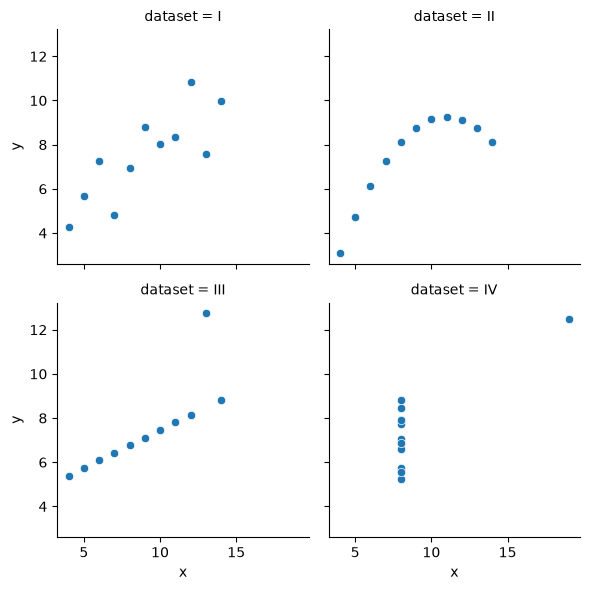

In [5]:
# RUN-TOGETHER:
sns.relplot(data=anscombe, x='x', y='y', col='dataset',
            col_wrap=2, height=3)
plt.show()

Identical statistics, four completely different stories: one clean line, one curve, one line dragged by a single outlier, one vertical stack. 

Note: A statistical summary compresses information, a plot helps reveal details.  **Both** are necessary for data science. Never trust a data description without looking.

## 1.2 One variable: histograms

**Definition.** A *histogram* is a graphical representation used to visualize the frequency distribution of a dataset. It shows how many data points fall into specific ranges of values. 

- **Bins:** The entire range of data is divided into a series of non-overlapping, consecutive intervals called bins (or buckets).
- **Frequency:** The height of the bar for each bin represents the number of data points (frequency) that fall within that interval.
- **Visualization:** Unlike a bar chart (which compares discrete categories), a histogram is used for continuous or quantitative data to show the "shape" of the data.

We can do this in one line in seaborn:

In [7]:
# RUN-TOGETHER
penguins = sns.load_dataset('penguins')
penguins.head(3)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female


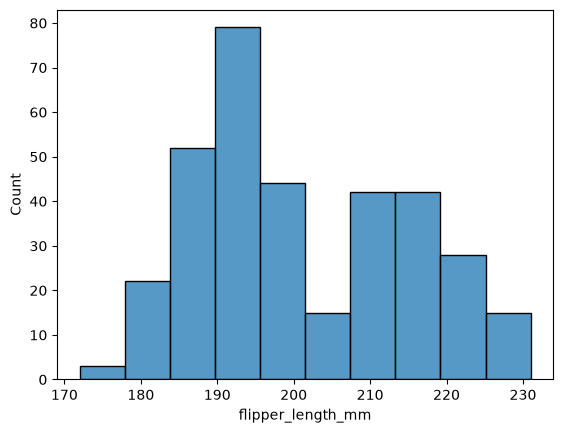

In [ ]:
# RUN-TOGETHER
sns.histplot(data=penguins, x='flipper_length_mm')
plt.show()

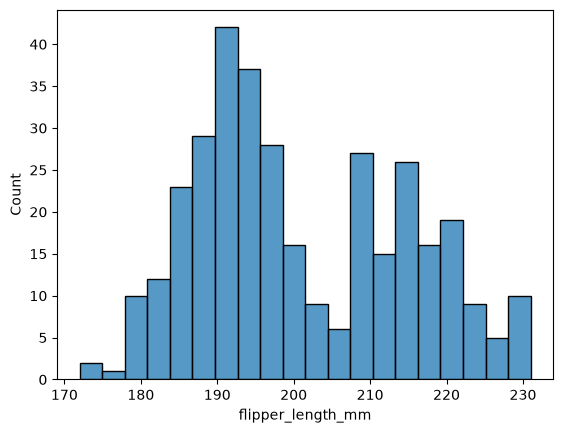

In [ ]:
# RUN-TOGETHER
? sns.histplot

sns.histplot(data=penguins, 
                x='flipper_length_mm', 
                bins=20)
plt.show()

> **Predict First.** That histogram looked a little lumpy, maybe two bumps. We have three penguin species. Predict: if we color the bars by species, will the bumps separate out? 

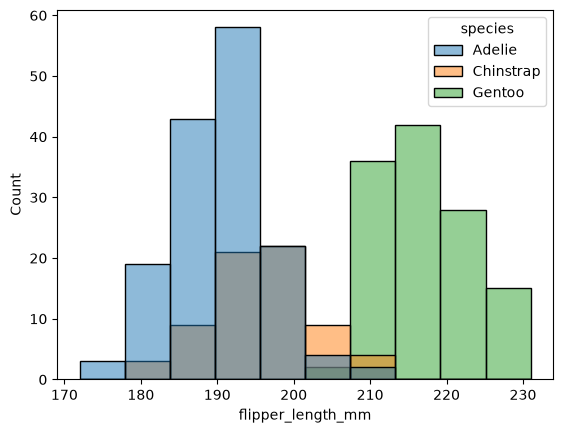

In [18]:
# FILL-IN-LIVE
# together: add a categorical split by filling in the hue column.
sns.histplot(data=penguins, x='flipper_length_mm', hue='species')
plt.show()
# The two bumps WERE the species. A hidden pattern, now visible.

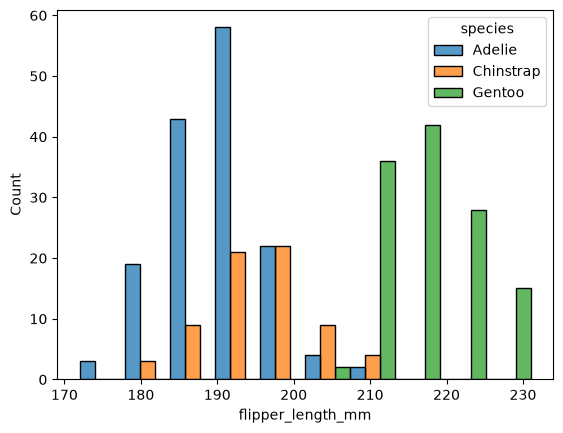

In [ ]:
sns.histplot(data=penguins, x='flipper_length_mm', 
                            hue='species', 
                            multiple="dodge")
plt.show()

> **Discuss.** The single-color histogram hid a real structure that the colored one revealed. What does this suggest about exploring a new dataset? What might you miss if you only ever computed one overall mean flipper length?

### 1.3 Comparing groups: boxplots

**Definition.** A *boxplot* (or box-and-whisker-plot) is a standardized way of displaying the distribution of a quantatative variable based on a five-number summary. It is used to visually identify the spread, skewness, and potential outliers in the numerical dataset. Boxplot are common tool for comparing  distribution accross groups in a categorical variable.

A boxplot consists of several key components derived from the data's distribution:

- Median (Q2): A line inside the box representing the middle value of the dataset (50th percentile).
- First Quartile (Q1): The bottom edge of the box, representing the 25th percentile (the median of the lower half of the data).
- Third Quartile (Q3): The top edge of the box, representing the 75th percentile (the median of the upper half of the data).
- Interquartile Range (IQR): The height of the box itself (Q3−Q1). It represents the middle 50% of the data.
- Whiskers: Lines extending from the top and bottom of the box. They typically extend to the furthest data points that fall within 1.5 × IQR from the edge of the box.
- Outliers: Individual points plotted beyond the whiskers. These are considered extreme values that fall significantly outside the rest of the data.


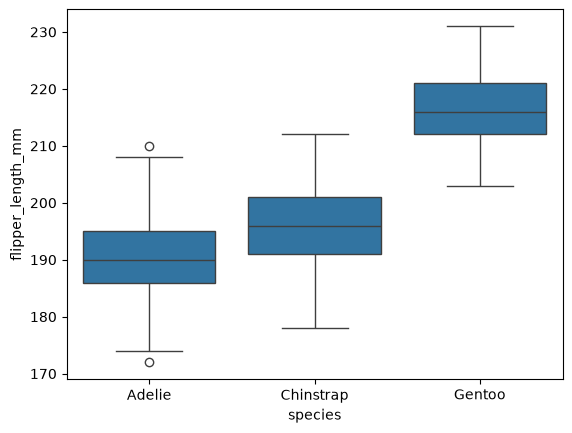

In [19]:
# RUN-TOGETHER
sns.boxplot(data=penguins, x='species', y='flipper_length_mm')
plt.show()

Now we add labels so the figure could stand on its own in a report.

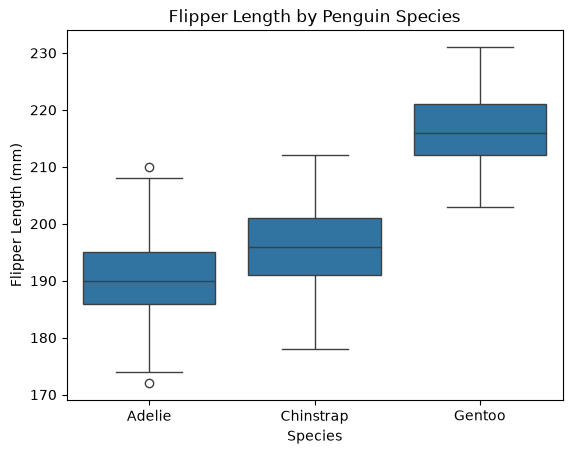

In [20]:
# FILL-IN
sns.boxplot(data=penguins, x='species', y='flipper_length_mm')
# give the plot an informative title and axis labels.
plt.title('Flipper Length by Penguin Species')
plt.xlabel('Species')
plt.ylabel('Flipper Length (mm)')
plt.show()

In [21]:
penguins.head(3)

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female


### Activity 1: One variable EDA
Pick a different numeric feature (`bill_length_mm`, `bill_depth_mm`, or `body_mass_g`) from the peguins dataset and explore it. Fill in the blanks; predict the shape before each plot.

In [ ]:
# Activity code (fill in the ____)
feature = _____     # fill in

# (1) Histogram of the feature, split by species or sex.
sns.histplot(data=penguins, x=feature, hue= ____ )   # fill in
plt.title('Distribution of ' + feature)
plt.show()

# (2) Boxplot of the feature across species or sex.
sns.boxplot(data=penguins, x= _____ , y= ____ )     # fill in
plt.show()

> Did your feature separate the as cleanly as flipper length did with species? Some features distinguish groups well and others do not, that difference is exactly what makes a feature useful for prediction later in the course.

---
# 2. Relationships, Log Scales, and Critique
---

## 2.1 Two variables: scatterplots

**Definition.** A *scatterplot* A scatterplot is a diagram that uses dots to represent the values for two different numeric variables. The position of each dot on the graph is determined by its x-coordinate (first variable) and y-coordinate (second variable). 

The main goal of a scatterplot is to visualize the relationship (correlation) between two continuous variables to see if they change together.

Scatterplots are commonly summarized by:
- Correlation
    - Positive Correlation: As x increases, y also increases (the dots trend upward from left to right).
    - Negative Correlation: As x increases, y decreases (the dots trend downward from left to right).
    - No Correlation: The dots appear randomly scattered with no discernible trend (the variables are independent).
- Strength of Relationship:
    - Strong: The dots are tightly clustered around a clear line or curve.
    - Weak: The dots are widely dispersed, making the trend harder to see.
- Form (Shape):
    - Linear: The relationship follows a straight line.
    - Non-linear/Curvilinear: The relationship follows a curve (e.g., exponential or logarithmic).
- Outliers:
    - Points that fall far away from the general cluster of data, indicating unusual observations or errors in data collection.

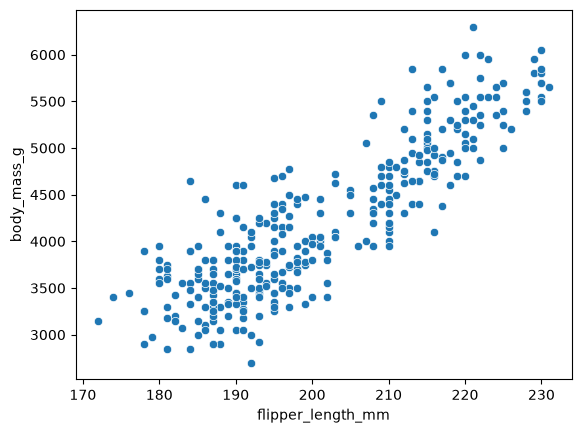

In [24]:
# RUN-TOGETHER
sns.scatterplot(data=penguins, x='flipper_length_mm', y='body_mass_g')
plt.show()

> **Predict, then run.** We know these two variables are strongly correlated overall (we saw that in Module 4). If we color by species, will we see one big cloud, or separate clusters? 

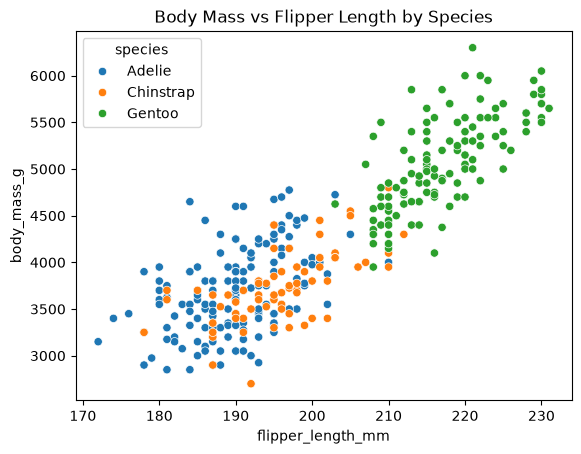

In [25]:
# FILL-IN
# Color the points by species to reveal structure.
sns.scatterplot(data=penguins, x='flipper_length_mm',
                y='body_mass_g', hue='species') 
plt.title('Body Mass vs Flipper Length by Species')
plt.show()

> **Discuss.** The overall trend is there but each species also forms its own cluster. This is a preview of a deep idea: a pattern in the whole dataset can look different once you account for groups.

## 2.2 See it all at once: pairplot

A a "quick overview" tool for Exploratory Data Analysis (EDA) are pairplots. `sns.pairplot` creates a grid matrix of plots that allows us to visualize every possible relationship between all numeric variables in the dataset simultaneously.

The Matrix Structure. If your dataset has N numeric columns, pairplot creates an NxN grid of plots. The grid is divided into two sections:

1. The Diagonal (Univariate Plots)
The plots running from the top-left to the bottom-right represent one single variable at a time.

    - What they show: The distribution (shape) of that specific variable.
    - Default type: Usually a histogram (showing frequency) or a KDE (Kernel Density Estimate, a smooth curve).
    - Purpose: To show if a single variable is normally distributed, skewed, or has multiple peaks.
2. The Off-Diagonal (Bivariate Plots)
All the other plots (above and below the diagonal) represent the relationship between two different variables.
    - What they show: How one variable changes in relation to another.
    - Default type: A scatterplot.
    - Purpose: To instantly spot correlations (linear or non-linear), clusters, or outliers between variable pairs.

When you meet a new dataset, `pairplot` is the fastest way to get oriented.

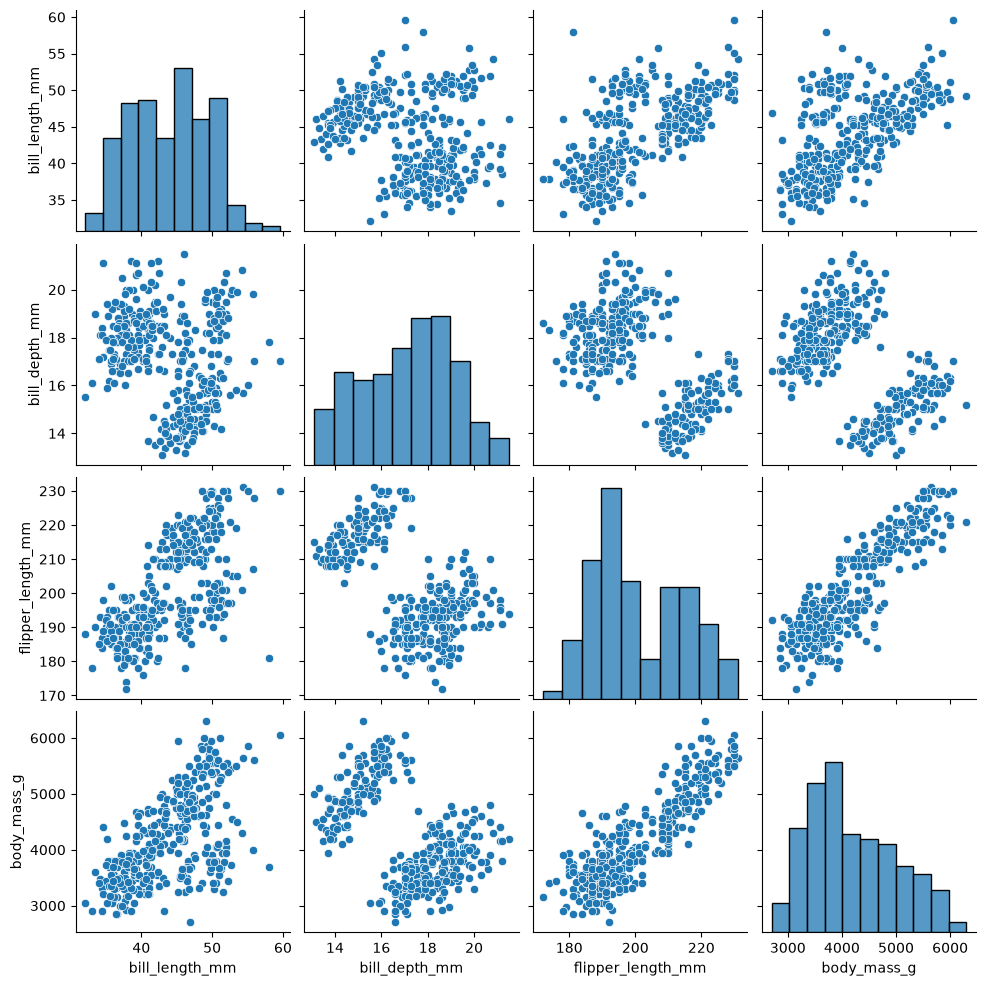

In [ ]:
# RUN-TOGETHER
sns.pairplot(penguins)
plt.show()

>Discussion: 

- What do we notice?  
- What information do we get from the graphs?
- What (statistical) qustions do we have?

### The Power of the hue Parameter

The most important feature of pairplot is the hue argument. If you provide a categorical column to hue, Seaborn will:

- Color-code the dots in the scatterplots by category.
- Overlay multiple distribution curves in the diagonal plots.

This allows us to see if different groups (e.g., "Male" vs "Female" or "Species A" vs "Species B") behave differently across every dimension of your data.

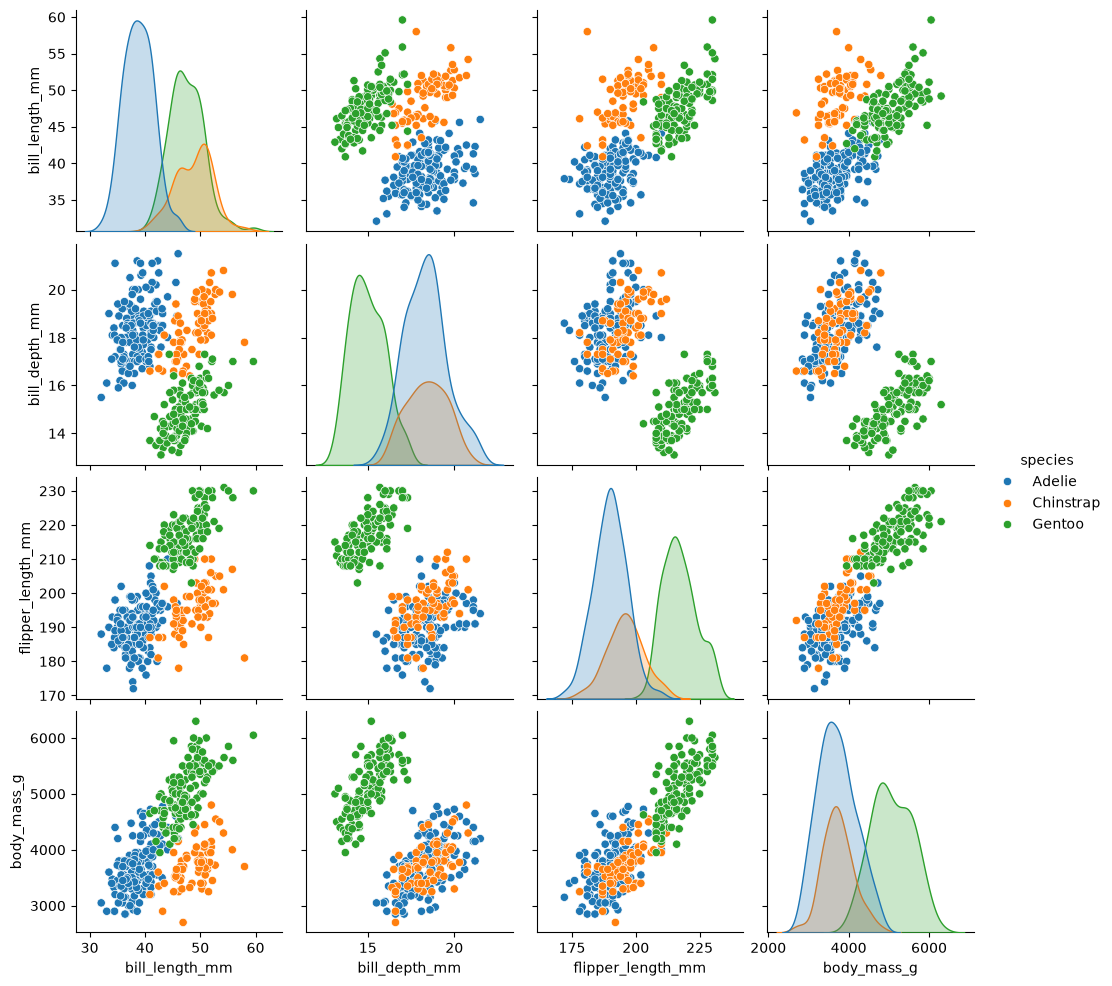

In [30]:
sns.pairplot(penguins, hue = 'species')
plt.show()

>Discussion: 

Scanning the pairplot, which *pair* of measurements separates the three species most cleanly? 

If you had to pick just two features to tell the species apart, which would you choose, and how can you tell from these plots?

### Example: Gapminder Data

Gapminder (https://www.gapminder.org/teaching/materials/) is an independent educational non-proﬁt ﬁghting global misconceptions. 

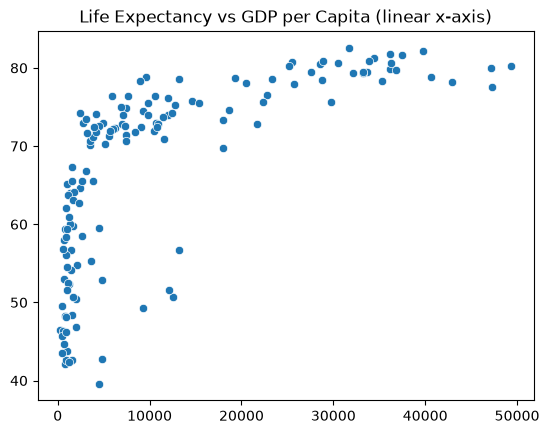

In [ ]:
## Example - Life Expentancy vs GDP from 2007
import numpy as np

# GDP per capita (in US dollars) 
gdp_cap = np.array([974.5803384, 5937.029525999999, 6223.367465, 4797.231267, 12779.37964, 34435.367439999995, 36126.4927, 29796.04834, 1391.253792, 33692.60508, 1441.284873, 3822.137084, 7446.298803, 12569.85177, 9065.800825, 10680.79282, 1217.032994, 430.0706916, 1713.778686, 2042.09524, 36319.23501, 706.016537, 1704.063724, 13171.63885, 4959.114854, 7006.580419, 986.1478792, 277.5518587, 3632.557798, 9645.06142, 1544.750112, 14619.222719999998, 8948.102923, 22833.30851, 35278.41874, 2082.4815670000003, 6025.374752000001, 6873.262326000001, 5581.180998, 5728.353514, 12154.08975, 641.3695236000001, 690.8055759, 33207.0844, 30470.0167, 13206.48452, 752.7497265, 32170.37442, 1327.60891, 27538.41188, 5186.050003, 942.6542111, 579.2317429999999, 1201.637154, 3548.3308460000003, 39724.97867, 18008.94444, 36180.78919, 2452.210407, 3540.651564, 11605.71449, 4471.061906, 40675.99635, 25523.2771, 28569.7197, 7320.880262000001, 31656.06806, 4519.461171, 1463.249282, 1593.06548, 23348.139730000003, 47306.98978, 10461.05868, 1569.331442, 414.5073415, 12057.49928, 1044.770126, 759.3499101, 12451.6558, 1042.581557, 1803.151496, 10956.99112, 11977.57496, 3095.7722710000003, 9253.896111, 3820.17523, 823.6856205, 944.0, 4811.060429, 1091.359778, 36797.93332, 25185.00911, 2749.320965, 619.6768923999999, 2013.977305, 49357.19017, 22316.19287, 2605.94758, 9809.185636, 4172.838464, 7408.905561, 3190.481016, 15389.924680000002, 20509.64777, 19328.70901, 7670.122558, 10808.47561, 863.0884639000001, 1598.435089, 21654.83194, 1712.472136, 9786.534714, 862.5407561000001, 47143.17964, 18678.31435, 25768.25759, 926.1410683, 9269.657808, 28821.0637, 3970.095407, 2602.394995, 4513.480643, 33859.74835, 37506.41907, 4184.548089, 28718.27684, 1107.482182, 7458.396326999999, 882.9699437999999, 18008.50924, 7092.923025, 8458.276384, 1056.380121, 33203.26128, 42951.65309, 10611.46299, 11415.80569, 2441.576404, 3025.349798, 2280.769906, 1271.211593, 469.70929810000007])
# Life Expectancy from 2007
life_exp = np.array([43.828, 76.423, 72.301, 42.731, 75.32, 81.235, 79.829, 75.635, 64.062, 79.441, 56.728, 65.554, 74.852, 50.728, 72.39, 73.005, 52.295, 49.58, 59.723, 50.43, 80.653, 44.74100000000001, 50.651, 78.553, 72.961, 72.889, 65.152, 46.462, 55.322, 78.782, 48.328, 75.748, 78.273, 76.486, 78.332, 54.791, 72.235, 74.994, 71.33800000000001, 71.878, 51.57899999999999, 58.04, 52.947, 79.313, 80.657, 56.735, 59.448, 79.406, 60.022, 79.483, 70.259, 56.007, 46.388000000000005, 60.916, 70.19800000000001, 82.208, 73.33800000000001, 81.757, 64.69800000000001, 70.65, 70.964, 59.545, 78.885, 80.745, 80.546, 72.567, 82.603, 72.535, 54.11, 67.297, 78.623, 77.58800000000001, 71.993, 42.592, 45.678, 73.952, 59.443000000000005, 48.303, 74.241, 54.467, 64.164, 72.801, 76.195, 66.803, 74.543, 71.164, 42.082, 62.069, 52.906000000000006, 63.785, 79.762, 80.204, 72.899, 56.867, 46.859, 80.196, 75.64, 65.483, 75.53699999999999, 71.752, 71.421, 71.688, 75.563, 78.098, 78.74600000000001, 76.442, 72.476, 46.242, 65.528, 72.777, 63.062, 74.002, 42.568000000000005, 79.972, 74.663, 77.926, 48.159, 49.339, 80.941, 72.396, 58.556, 39.613, 80.884, 81.70100000000001, 74.143, 78.4, 52.517, 70.616, 58.42, 69.819, 73.923, 71.777, 51.542, 79.425, 78.242, 76.384, 73.747, 74.249, 73.422, 62.698, 42.38399999999999, 43.487])

sns.scatterplot(x= gdp_cap, y=life_exp)
plt.title('Life Expectancy vs GDP per Capita (linear x-axis)')
plt.show()

> **Predict.** On the linear axis, the poorer countries are all squashed against the left edge, hard to distinguish. A **log scale** on the x-axis spreads them out. Predict how the shape changes, then run.

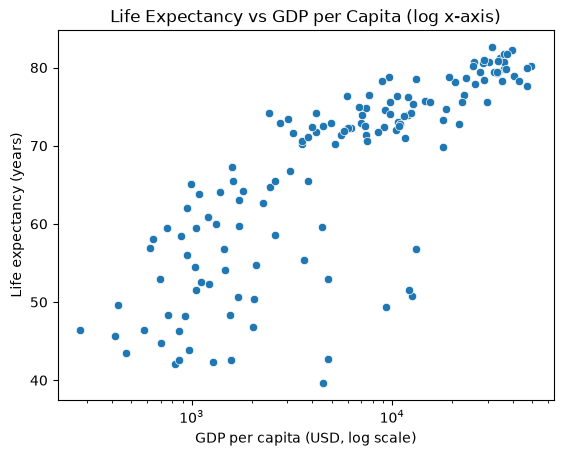

In [35]:
# FILL-IN-LIVE
sns.scatterplot(x=gdp_cap, y=life_exp)
# switch the x-axis to a logarithmic scale.
plt.xscale('log')   
plt.title('Life Expectancy vs GDP per Capita (log x-axis)')
plt.xlabel('GDP per capita (USD, log scale)')
plt.ylabel('Life expectancy (years)')
plt.show()

On the log axis the relationship becomes clear and roughly linear: each *multiplication scale* of income buys a similar gain in life expectancy, up to a point. 

*The scale you choose is part of the story you tell*, which is exactly why the next section is about honesty.

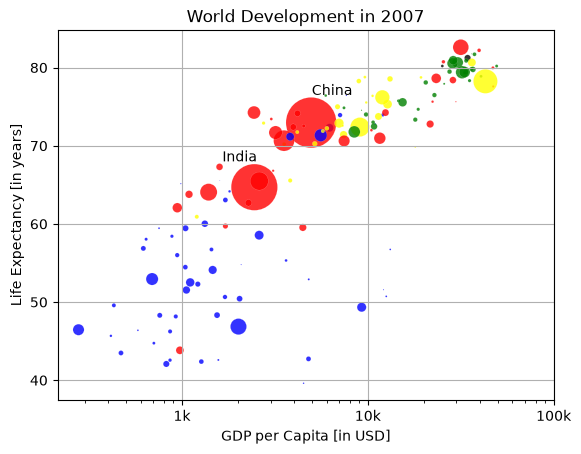

In [51]:
# Example - Gapminder Data

# Add in some population data
pop = [31.889923, 3.600523, 33.333216, 12.420476, 40.301927, 20.434176, 8.199783, 0.708573, 150.448339, 10.392226, 8.078314, 9.119152, 4.552198, 1.639131, 190.010647, 7.322858, 14.326203, 8.390505, 14.131858, 17.696293, 33.390141, 4.369038, 10.238807, 16.284741, 1318.683096, 44.22755, 0.71096, 64.606759, 3.80061, 4.133884, 18.013409, 4.493312, 11.416987, 10.228744, 5.46812, 0.496374, 9.319622, 13.75568, 80.264543, 6.939688, 0.551201, 4.906585, 76.511887, 5.23846, 61.083916, 1.454867, 1.688359, 82.400996, 22.873338, 10.70629, 12.572928, 9.947814, 1.472041, 8.502814, 7.483763, 6.980412, 9.956108, 0.301931, 1110.396331, 223.547, 69.45357, 27.499638, 4.109086, 6.426679, 58.147733, 2.780132, 127.467972, 6.053193, 35.610177, 23.301725, 49.04479, 2.505559, 3.921278, 2.012649, 3.193942, 6.036914, 19.167654, 13.327079, 24.821286, 12.031795, 3.270065, 1.250882, 108.700891, 2.874127, 0.684736, 33.757175, 19.951656, 47.76198, 2.05508, 28.90179, 16.570613, 4.115771, 5.675356, 12.894865, 135.031164, 4.627926, 3.204897, 169.270617, 3.242173, 6.667147, 28.674757, 91.077287, 38.518241, 10.642836, 3.942491, 0.798094, 22.276056, 8.860588, 0.199579, 27.601038, 12.267493, 10.150265, 6.144562, 4.553009, 5.447502, 2.009245, 9.118773, 43.997828, 40.448191, 20.378239, 42.292929, 1.133066, 9.031088, 7.554661, 19.314747, 23.174294, 38.13964, 65.068149, 5.701579, 1.056608, 10.276158, 71.158647, 29.170398, 60.776238, 301.139947, 3.447496, 26.084662, 85.262356, 4.018332, 22.211743, 11.746035, 12.311143]

# Color by continent
col = ['red', 'green', 'blue', 'blue', 'yellow', 'black', 'green', 'red', 'red', 'green', 'blue', 'yellow', 'green', 'blue', 'yellow', 'green', 'blue', 'blue', 'red', 'blue', 'yellow', 'blue', 'blue', 'yellow', 'red', 'yellow', 'blue', 'blue', 'blue', 'yellow', 'blue', 'green', 'yellow', 'green', 'green', 'blue', 'yellow', 'yellow', 'blue', 'yellow', 'blue', 'blue', 'blue', 'green', 'green', 'blue', 'blue', 'green', 'blue', 'green', 'yellow', 'blue', 'blue', 'yellow', 'yellow', 'red', 'green', 'green', 'red', 'red', 'red', 'red', 'green', 'red', 'green', 'yellow', 'red', 'red', 'blue', 'red', 'red', 'red', 'red', 'blue', 'blue', 'blue', 'blue', 'blue', 'red', 'blue', 'blue', 'blue', 'yellow', 'red', 'green', 'blue', 'blue', 'red', 'blue', 'red', 'green', 'black', 'yellow', 'blue', 'blue', 'green', 'red', 'red', 'yellow', 'yellow', 'yellow', 'red', 'green', 'green', 'yellow', 'blue', 'green', 'blue', 'blue', 'red', 'blue', 'green', 'blue', 'red', 'green', 'green', 'blue', 'blue', 'green', 'red', 'blue', 'blue', 'green', 'green', 'red', 'red', 'blue', 'red', 'blue', 'yellow', 'blue', 'green', 'blue', 'green', 'yellow', 'yellow', 'yellow', 'red', 'red', 'red', 'blue', 'blue']

# Add population as a size component 's'
# Add continent color as a color component 'c'
# Add some transparency using component 'alpha' (values between 0 and 1)
sns.scatterplot(x=gdp_cap, y=life_exp, s = pop, c = col, alpha = 0.8)

# Previous customizations
plt.xscale('log')
plt.xlabel('GDP per Capita [in USD]')
plt.ylabel('Life Expectancy [in years]')
plt.title('World Development in 2007')
plt.xticks([1000, 10000, 100000],['1k', '10k', '100k'])

# Additional customizations
# Add text to specific x,y coordinates
plt.text(1650, 68, 'India')
plt.text(5000, 76.5, 'China')

# Add grid() call to add in a reference grid
plt.grid(True)

# Display the plot
plt.show()

### 2.4 Plots can mislead: a critique studio

Because a plot tells a story, a careless or dishonest plot tells a false one. The most common trick is a truncated y-axis that exaggerates a difference. We build the same data two ways.

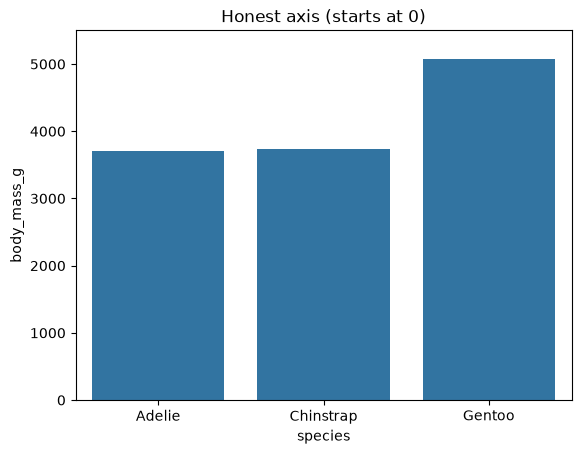

In [36]:
# RUN-TOGETHER
means = penguins.groupby('species')['body_mass_g'].mean().reset_index()

# HONEST: y-axis starts at 0
sns.barplot(data=means, x='species', y='body_mass_g')
plt.ylim(0, 5500)
plt.title('Honest axis (starts at 0)')
plt.show()

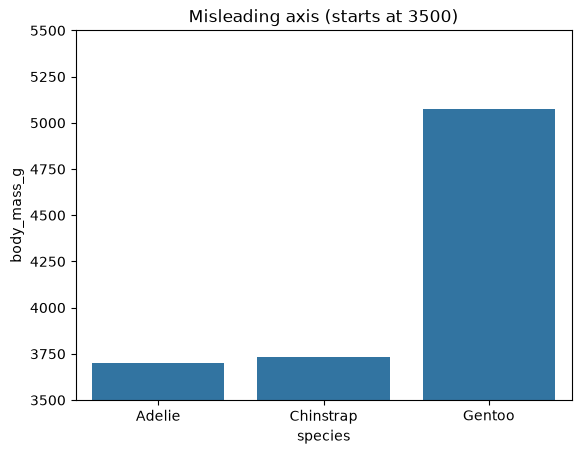

In [37]:
# RUN-TOGETHER
# MISLEADING: y-axis starts at 3500, exaggerating the gaps
sns.barplot(data=means, x='species', y='body_mass_g')
plt.ylim(3500, 5500)
plt.title('Misleading axis (starts at 3500)')
plt.show()

> **Think-pair-share (critique).** The two charts show the *identical* data. Describe how the second one changes the impression a casual reader gets. When might starting an axis above zero be legitimate, and when is it deceptive? Who bears responsibility for how a chart is read, the maker or the viewer?

### Activity 2: a one-question EDA

Choose ONE question about the penguins you find interesting, for example: 
- *Do the sexes differ in body mass within a species?*
- *Which island has the heaviest penguins?* 
- *Which two measurements best separate the species?* 

Then produce the **single plot** that best answers it, fully labeled, and write your finding.

Starter code chunck below. Adapt it to your question.

In [ ]:
# One-question EDA (edit freely)
import seaborn as sns
import matplotlib.pyplot as plt
penguins = sns.load_dataset('penguins')

# Our question:
# 

# Plot:
sns.______(data=penguins, ____ )
plt.title('...write an informative title...')
plt.xlabel('...')
plt.ylabel('...')
plt.show()

# Our finding (one or two sentences):
# 

We now have Python, NumPy, and visualization, the toolkits for the EXPLORE stage. Next we bring in pandas and turn these skills loose on full datasets.